In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/loan_approval_dataset.csv")
print(df)

      loan_id   no_of_dependents      education  self_employed   income_annum  \
0           1                  2       Graduate             No        9600000   
1           2                  0   Not Graduate            Yes        4100000   
2           3                  3       Graduate             No        9100000   
3           4                  3       Graduate             No        8200000   
4           5                  5   Not Graduate            Yes        9800000   
...       ...                ...            ...            ...            ...   
4264     4265                  5       Graduate            Yes        1000000   
4265     4266                  0   Not Graduate            Yes        3300000   
4266     4267                  2   Not Graduate             No        6500000   
4267     4268                  1   Not Graduate             No        4100000   
4268     4269                  1       Graduate             No        9200000   

       loan_amount   loan_t

In [2]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [3]:
df.drop(columns=['loan_id'],inplace=True)
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [5]:
df.dtypes

,0
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64
luxury_assets_value,int64


In [6]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
columns_to_encode=[' education',' self_employed',' loan_status']
for column in columns_to_encode:
  df[column]=lb.fit_transform(df[column])
df.dtypes

,0
no_of_dependents,int64
education,int64
self_employed,int64
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64
luxury_assets_value,int64


In [7]:
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [8]:
x=df.iloc[:,:-1].values
x

array([[       2,        0,        0, ..., 17600000, 22700000,  8000000],
       [       0,        1,        1, ...,  2200000,  8800000,  3300000],
       [       3,        0,        0, ...,  4500000, 33300000, 12800000],
       ...,
       [       2,        1,        0, ..., 12400000, 18100000,  7300000],
       [       1,        1,        0, ...,   700000, 14100000,  5800000],
       [       1,        0,        0, ..., 11800000, 35700000, 12000000]])

In [9]:
y=df.iloc[:,-1].values
y

array([0, 1, 1, ..., 1, 0, 0])

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
x_train

array([[       4,        1,        0, ...,  1100000,  9100000,  1500000],
       [       3,        1,        1, ...,  3600000, 36500000, 12800000],
       [       4,        0,        1, ...,  2300000,  8400000,  2000000],
       ...,
       [       4,        1,        1, ..., 10600000, 28700000,  5400000],
       [       2,        1,        1, ...,  1300000, 19800000,  9600000],
       [       4,        0,        0, ...,  3700000, 24700000,  4600000]])

In [11]:
x_test

array([[       5,        0,        0, ..., 10000000, 15700000,  7300000],
       [       2,        0,        0, ...,  9500000, 17800000,  6700000],
       [       3,        0,        0, ..., 16200000, 28500000,  6600000],
       ...,
       [       5,        1,        1, ..., 10300000, 22000000,  9100000],
       [       4,        1,        0, ...,  4000000, 21100000,  3400000],
       [       0,        1,        1, ...,   700000,  3500000,   400000]])

In [12]:
y_train

array([1, 0, 0, ..., 1, 1, 0])

In [13]:
y_test

array([1, 0, 1, ..., 0, 1, 0])

## KNearestNeighbor (KNN) Alghorithum

In [14]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
scalar.fit(x_train)
x_train=scalar.transform(x_train)
x_test=scalar.transform(x_test)
x_test

array([[ 1.52932527, -0.99266412, -1.0148356 , ...,  1.15114098,
         0.0528932 ,  0.71644722],
       [-0.25151024, -0.99266412, -1.0148356 , ...,  1.03686597,
         0.28186474,  0.53156293],
       [ 0.3421016 , -0.99266412, -1.0148356 , ...,  2.5681511 ,
         1.44852927,  0.50074889],
       ...,
       [ 1.52932527,  1.00739009,  0.98538127, ...,  1.21970598,
         0.73980783,  1.27110006],
       [ 0.93571344,  1.00739009, -1.0148356 , ..., -0.22015914,
         0.64167717, -0.48530061],
       [-1.43873391,  1.00739009,  0.98538127, ..., -0.97437421,
        -1.27732243, -1.40972202]])

In [15]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)


KNeighborsClassifier(n_neighbors=7)

In [16]:
y_pred=knn.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 0])

In [17]:
from sklearn.metrics import confusion_matrix
cmd=confusion_matrix(y_test,y_pred)
cmd

array([[716,  94],
       [ 62, 409]])

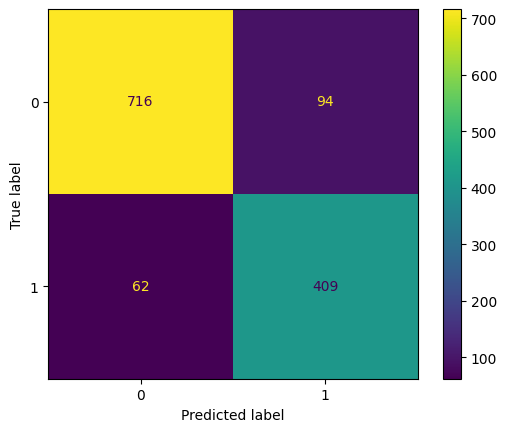

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(cmd)
disp.plot()

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8782201405152225

In [20]:
knn.predict([[2,0,1,9600000,2990000,12,778,2400000,1760000,227000,8000000]])

array([0])

### **RandomForestClassifier** **Alghorithum**

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100)
rf.fit(x_train,y_train)

RandomForestClassifier()

In [23]:
y_pred=rf.predict(x_test)
y_pred

array([1, 0, 1, ..., 0, 1, 0])

In [24]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[802,   8],
       [ 19, 452]])

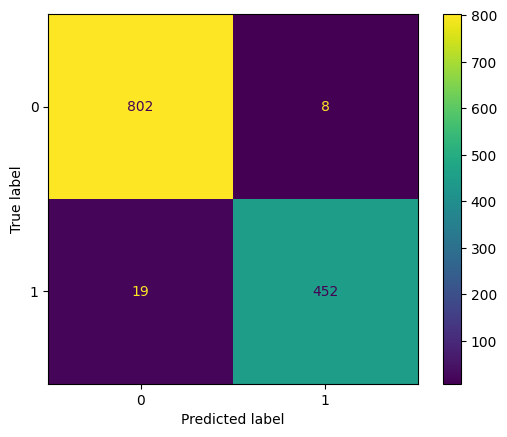

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(cm)
disp.plot()

In [26]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9789227166276346

In [27]:
rf.predict([[2,0,0,960000,1200000,7,778,240000,1760000,7600000,7000000]])

array([0])